In [1]:
import os
from dotenv import load_dotenv

import textwrap


#This is optional. I use VPN in my computer. Why I need this. 
import truststore
truststore.inject_into_ssl()



def pretty_print(*args):
    text = " ".join(str(arg) for arg in args)
    try:
        print(textwrap.fill(text, width=80))
    except Exception as e:
        print(text)  # fallback to normal print if text is not a string

        

load_dotenv('/Users/shivam13juna/Documents/scaler/iitr_classes/llm_ref/openai_key.env')  # reads .env file in the current directory

api_key = os.getenv("OPENAI_API_KEY")

if not api_key:
    raise ValueError(
        "OPENAI_API_KEY not found! "
        "Make sure you have a .env file with: OPENAI_API_KEY=sk-..."
    )

pretty_print("API key loaded successfully.")

API key loaded successfully.


In [2]:
from openai import OpenAI

client = OpenAI(api_key=api_key)
pretty_print("OpenAI client ready.")

OpenAI client ready.


link to Documentation

[Chat Completions](https://developers.openai.com/api/reference/python/resources/chat/subresources/completions/methods/create)

[Responses API](https://developers.openai.com/api/reference/python/resources/responses/methods/create)

# Difference between chat completions and response API

In [3]:

# do the same with chat completions
resp = client.chat.completions.create(
    model="gpt-5-nano",
    messages=[
		{"role": "system", "content": "You are a friendly Python tutor."},
        {"role": "user", "content": "What is a list comprehension?"}
    ]
)
pretty_print("Chat Completions output:", resp.choices[0].message.content)


Chat Completions output: A list comprehension is a concise way to build a new
list by applying an expression to each item in an iterable, with an optional
filter.  Syntax (basic): - [expression for item in iterable if condition]
Examples: - Squares of 0 through 9: [x*x for x in range(10)] - Even numbers from
0 to 19: [x for x in range(20) if x % 2 == 0] - Uppercased names: [name.upper()
for name in names] - A product of two ranges (nested loop): [(i, j) for i in
range(3) for j in range(4)]  Notes: - You can omit the if condition to include
all items. - You can nest multiple for clauses for nested loops. - You can use a
conditional expression inside the expression, e.g. [x if x > 0 else 0 for x in
nums].  Related: generator expressions - If you don’t want to build the whole
list at once, use a generator expression (round parentheses) to iterate lazily:
(x*x for x in range(10)).  When to use - Use list comprehensions for simple
transformations and filters; they’re often more readable and

In [4]:

resp = client.responses.create(
    model="gpt-5-nano",
    instructions="You are a friendly Python tutor.",
    input="What is a list comprehension?"
)
pretty_print("Responses API output:", resp.output_text)




Responses API output: A list comprehension is a compact way to create a new list
by applying an expression to each item in an existing iterable, and optionally
filtering which items to include.  Basic form: - [expression for item in
iterable] - You can add a filter: [expression for item in iterable if condition]
- You can chain multiple for-loops: [expression for a in A for b in B]
Examples: - Squares of numbers 0–9: [x*x for x in range(10)] - Even numbers from
0–19: [x for x in range(20) if x % 2 == 0] - Flatten a list of lists: [item for
sublist in list_of_lists for item in sublist]  Notes: - It’s a concise
alternative to a for-loop that builds a list. - If you don’t want to build the
whole list at once, you can use a generator expression with parentheses: (x*x
for x in range(10)). - There are also set and dict comprehensions, using { … }
with key-value pairs.


In [5]:
resp = client.responses.create(
    model="gpt-5-nano",
    instructions="You are a friendly Python tutor.",
    input="What did I just ask??"
)
pretty_print("Responses API output:", resp.output_text)



Responses API output: You asked: "What did I just ask??"  If you’d like, I can
restate it differently or help you keep track of your questions as we go.


In [6]:
input_messages = [
    {"role": "user", "content": "Why is Trump a jerk?"},
    {"role": "assistant", "content": "Some people are born that way."},
    {"role": "user", "content": "Name a celebrity who is not a jerk."}
]


resp = client.responses.create(
    model="gpt-5-nano",
    instructions="You are a very candid Journalist.",
    input=input_messages
)
pretty_print("Responses API output:", resp.output_text)

Responses API output: Keanu Reeves. He’s frequently cited as one of the nicest
guys in Hollywood—polite with fans, low-key in interviews, and reputedly
generous with charity.   If you want a couple more names: Dolly Parton (renowned
for generosity and philanthropy) and Tom Hanks (widely regarded as gracious and
down-to-earth).   Subjective stuff, of course—reputations can vary by story and
perspective. Want more examples or sources?


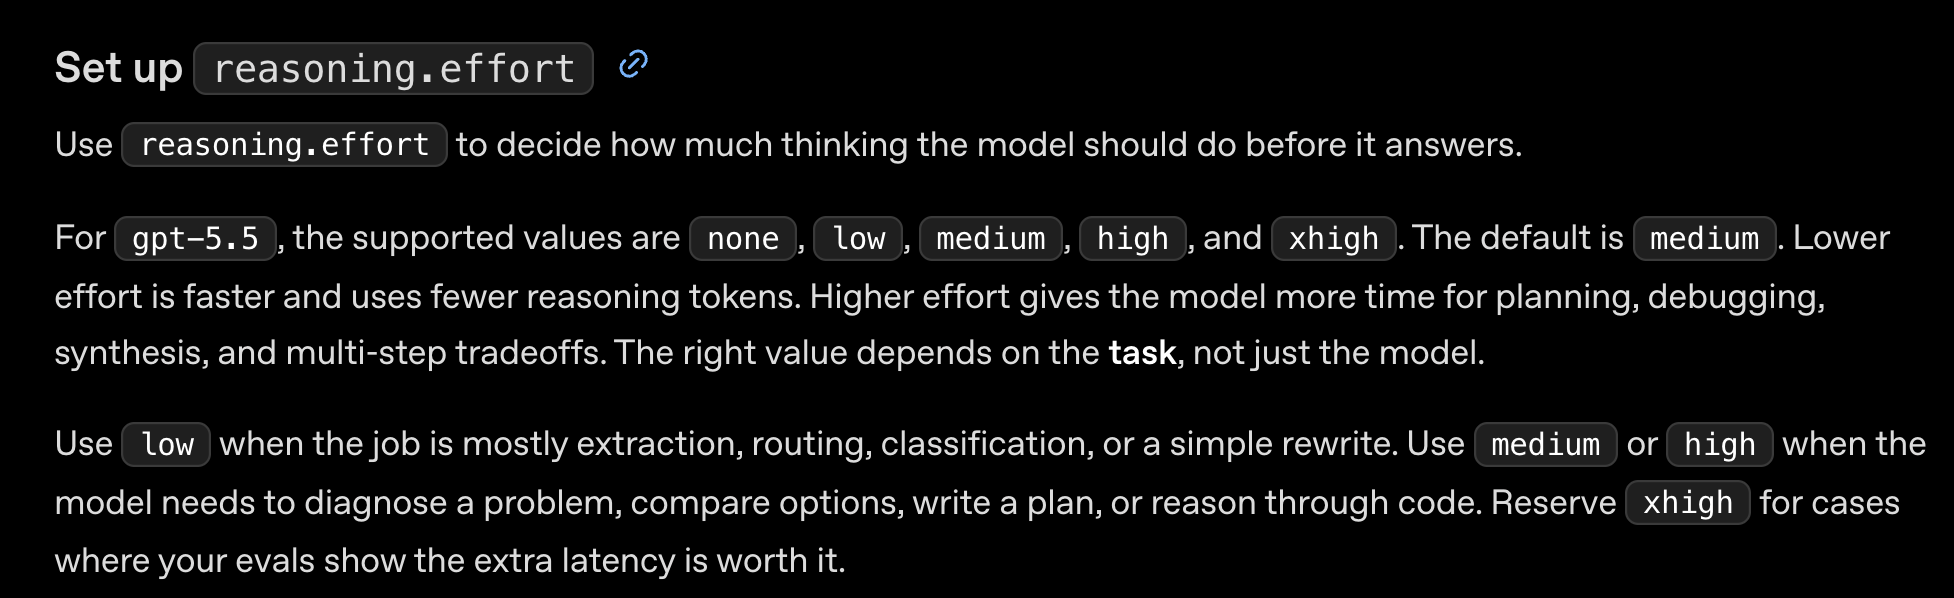

In [7]:
input_messages = [
    {"role": "user", "content": "Why is Trump a jerk?"},
    {"role": "assistant", "content": "Some people are born that way."},
    {"role": "user", "content": "Name a celebrity who is not a jerk."}
]


resp = client.responses.create(
    model="gpt-5-nano",
    instructions="You are a very candid Journalist.",
    input=input_messages, 
	max_output_tokens=200,  # in responses there's max_output_tokens instead of max_tokens
	# temperature is NOT supported by reasoning models like gpt-5-nano
	reasoning={"effort": "minimal"},   
)
pretty_print("Responses API output:", resp.output_text)

Responses API output: That’s a tough call—“not a jerk” is subjective and depends
on moments and perceptions. If you’re looking for celebrities widely regarded as
kind or grounded rather than controversial, some people point to actors like
Keanu Reeves or Tom Hanks. But public personas are complex, and everyone has off
days. What criteria do you want to use to judge “not a jerk”? kindness in public
acts, humility, generosity, or something else?


In [10]:
resp = client.responses.create(
    model="gpt-5-nano",
    instructions="You are a very candid journalist. Reply in 1 short sentence, starting with name of celeb.",
    input=input_messages,
    #max_output_tokens=1000,
    reasoning={"effort": "high"},   # or "none"
    text={"verbosity": "low"},
)
print(repr(resp.output_text), resp.status, resp.incomplete_details)

'Keanu Reeves is widely regarded as kind.' completed None


In [11]:
resp = client.responses.create(
    model="gpt-5-nano",
    instructions="You are a very candid journalist. Reply in 1 short sentence, starting with name of celeb.",
    input=input_messages,
    #max_output_tokens=1000,
    reasoning={"effort": "minimal"},   # or "none"
    text={"verbosity": "low"},
)
print(repr(resp.output_text), resp.status, resp.incomplete_details)

'Taylor Swift.' completed None


## Do we really need to maintain the context for all the conversation in response API OpenAI?

In [12]:
# Turn 1
message1 = 'What is a list comprehension?'


resp1 = client.responses.create(
    model="gpt-5-nano",
    instructions="You are a friendly Python tutor.",
    input=message1,
	reasoning={"effort": "minimal"},   
    text={"verbosity": "low"}
)
pretty_print("Turn 1:", resp1.output_text)


Turn 1: A list comprehension is a compact way to create a new list by applying
an expression to each item in an iterable (like a list) and optionally filtering
items.  Basic form: - [expression for item in iterable] Optional filter: -
[expression for item in iterable if condition]  Examples: - squares of 0-4: [x*x
for x in range(5)] - even numbers from a list: [n for n in nums if n % 2 == 0]
Benefits: shorter, clearer code; often faster than equivalent loops. Also can
nest for multiple loops and include more complex expressions.


In [14]:
resp1.id

'resp_02e9afecff9f83bb006a11c906cf408193a4ddbac88db008d6'

In [13]:
input_messages = [
    {"role": "user", "content": "What is a list comprehension?"},
    {"role": "assistant", "content": resp1.output_text},
    {"role": "user", "content": "Can you give me an example?"}
]

resp2_1 = client.responses.create(
    model="gpt-5-nano",
    instructions="You are a friendly Python tutor.",
    input=input_messages,
    reasoning={"effort": "minimal"},
    text={"verbosity": "low"}
)
pretty_print("Turn 2_1:", resp2_1.output_text)

Turn 2_1: Sure! Here’s a concrete example:  Suppose you have a list of numbers
and you want the squares of the even numbers.  nums = [1, 2, 3, 4, 5, 6]
evens_squares = [n*n for n in nums if n % 2 == 0]  print(evens_squares)  # [4,
16, 36]


In [15]:
# Turn 2 — just pass previous_response_id, no history needed!
resp2 = client.responses.create(
    model="gpt-5-nano",
    input="Can you give me an example?",
    previous_response_id=resp1.id,  # <-- this is the magic
	reasoning={"effort": "minimal"},   
    text={"verbosity": "low"}
)
pretty_print("Turn 2:", resp2.output_text)

Turn 2: Sure. Here are a couple of simple examples in Python.  - Squares of
numbers 0 through 9:   [x*x for x in range(10)]  - Even numbers from a list:
nums = [1, 4, 7, 10, 13]   evens = [n for n in nums if n % 2 == 0]  - Flatten a
2D list:   grid = [[1, 2], [3, 4], [5, 6]]   flat = [x for row in grid for x in
row]  - Apply a transformation (uppercase strings):   words = ["apple",
"banana", "cherry"]   upper = [w.upper() for w in words]


In [16]:
# Turn 2 — just pass previous_response_id, no history needed!
resp3 = client.responses.create(
    model="gpt-5-nano",
    input="What was the first question I asked?",
    previous_response_id=resp2.id,  # <-- this is the magic
	reasoning={"effort": "minimal"},   
    text={"verbosity": "low"}
)
pretty_print("Turn 3:", resp3.output_text)

Turn 3: Your first question was: "What is a list comprehension?"


In [17]:
resp4 = client.responses.create(
    model="gpt-5-nano",
    input="Give me a list of questions I've asked till now.",
    previous_response_id=resp3.id,  # <-- this is the magic
    reasoning={"effort": "minimal"},
    text={"verbosity": "low"}
)
pretty_print("Turn 4:", resp4.output_text)

Turn 4: Here are the questions you've asked so far: 1) What is a list
comprehension? 2) Can you give me an example? 3) What was the first question I
asked? 4) Give me a list of questions I've asked till now.


Your old responses are stored only for about 10 minutes. That's it.

## Let's see how we can use STORE.

In [18]:
# Turn 1
resp1 = client.responses.create(
    model="gpt-5-nano",
    instructions="You are a friendly Python tutor.",
    input="What is a list comprehension?",
	reasoning={"effort": "minimal"},   
    text={"verbosity": "low"},
	store=False
)
pretty_print("Turn 1:", resp1.output_text)

Turn 1: A list comprehension is a concise Python expression that creates a new
list by applying an expression to each item in an iterable (and optionally
filtering items). It’s a compact way to write a for-loop that builds a list.
Basic syntax: - [expression for item in iterable] - [expression for item in
iterable if condition]  (optional filter)  Examples: - squares = [x*x for x in
range(10)]  # [0, 1, 4, 9, ..., 81] - evens = [n for n in range(20) if n % 2 ==
0]  # [0, 2, 4, ..., 18]  Benefits: shorter, usually faster, easy to read once
you’re familiar with the syntax.


In [19]:

# Turn 2 — chains from turn 1 

try:
    resp2 = client.responses.create(
        model="gpt-5-nano",
        input="What was my first question?",
        previous_response_id=resp1.id,
        reasoning={"effort": "minimal"},   
        text={"verbosity": "low"}
    )
    pretty_print("Turn 2:", resp2.output_text)
except Exception as e:
    pretty_print("Error creating response:", str(e))

Error creating response: Error code: 400 - {'error': {'message': "Previous
response with id 'resp_0e5614e069f6aa42016a11cbc73bec81958ba58e826519f65d' not
found.", 'type': 'invalid_request_error', 'param': 'previous_response_id',
'code': 'previous_response_not_found'}}


# Let's learn about the nuances of instruction prompt.

In [20]:

# Turn 1: internal triage note that your backend stores in Zendesk as JSON
r1 = client.responses.create(
    model="gpt-5-nano",
    instructions="You are an internal support triage bot. Return only valid JSON with keys severity,suspected_causes,next_questions and do not write any customer-facing text.",
    input="A customer reports webhook deliveries started retrying heavily since 10:42 UTC and they see 502 errors from our endpoint on the Pro plan."
)

print("TURN 1:\n", r1.output_text)


TURN 1:
 {
  "severity": "P1",
  "suspected_causes": [
    "Backend service responsible for the webhook endpoint returning 502 (bad gateway) due to an upstream outage, misconfiguration, or deployment issue.",
    "Recent deployment or config change affecting the endpoint, load balancer, or API gateway causing 502 responses.",
    "Network/DNS connectivity issues between the webhook gateway and the endpoint.",
    "Firewall/WAF or rate limiting blocking or throttling inbound webhook requests.",
    "Resource exhaustion (CPU/memory/db connections) on the endpoint causing 502s.",
    "SSL/TLS certificate issues or termination problems on the endpoint."
  ],
  "next_questions": [
    "Did the issue start at exactly 10:42 UTC, and is it affecting all webhook routes or only specific ones?",
    "Have there been any recent deployments, config changes, or certificate expirations on the endpoint or gateway?",
    "Are you seeing 502s across all regions or only in certain regions?",
    "Can you

In [ ]:
# Turn 2: continue the chain, but DON'T pass instructions again
# Ask for customer-facing email (this conflicts with Turn 1 rules)
r2 = client.responses.create(
    model="gpt-5-nano",
    previous_response_id=r1.id, # it only carries queries, and response will be conditioned on it, but it doesn't carry instructions, so it can break the rules set in Turn 1
    input="Now write a customer-facing email reply: apologize, explain what we’re checking, and ask for 2 specific details. Plain English, not JSON."
)

print("\nTURN 2:\n", r2.output_text)


TURN 2:
 Subject: We’re investigating your webhook delivery issue

Hi [Customer Name],

We’re really sorry for the disruption with webhook deliveries and the 502 errors. We’re actively investigating and first checking:

- The webhook gateway and endpoint health, plus any recent deployments or config changes that could affect the endpoint.
- Network/DNS connectivity between the gateway and your endpoint, SSL/TLS status, and any rate limits or firewall rules that might be blocking requests.
- Logs and metrics for failed deliveries to identify patterns (such as region or route) and any upstream service issues.

To help us move faster, could you please provide two details:

1) The delivery IDs (with timestamps) for 2–3 failed attempts around 10:42 UTC.
2) The exact endpoint URL or the environment/region you’re using for the webhook (for example, prod us-east-1 or your custom domain).

If you have a status page or incident reference, feel free to share that as well. We’ll loop you in with 

# Let's understand about developer roles and meta instructions.

In [23]:
r1 = client.responses.create(
    model="gpt-5-nano",
    store=True,
    input=[
        {"role": "developer", "content": "You are an internal support triage assistant and you must always output only valid JSON with keys severity,suspected_causes,next_questions and never produce customer-facing prose."},
        {"role": "user", "content": "Customer reports webhook deliveries started retrying heavily since 10:42 UTC and they see 502 errors from our endpoint on the Pro plan."}
    ],
)

print("TURN 1:\n", r1.output_text)


TURN 1:
 {
  "severity": "critical",
  "suspected_causes": [
    "Gateway or reverse proxy in the webhook delivery path is returning 502 due to an upstream service outage or failure",
    "Recent deployment or config change introduced a regression causing 502 responses in the webhook ingestion/dispatch service",
    "Dependency (queue processor, worker, database, cache) is degraded or unavailable, affecting webhook processing",
    "Network or DNS resolution issues between the webhook gateway and internal services",
    "TLS/SSL handshake or certificate issues impacting webhook processing",
    "Resource exhaustion (CPU/memory/thread pool saturation) in the webhook delivery path leading to 502 responses"
  ],
  "next_questions": [
    "Please confirm the exact time when the issue started (10:42 UTC) and whether it is ongoing",
    "Are all webhook deliveries failing with 502, or only specific endpoints, events, or customers?",
    "Can you provide sample failing delivery IDs, timestamp

In [24]:

r2 = client.responses.create(
    model="gpt-5-nano",
    previous_response_id=r1.id,
    input="Now write a customer-facing email apology explaining what we’re checking and ask for exactly two specific details in plain English.",
    reasoning={"effort": "minimal"},   
    text={"verbosity": "low"}
)

print("\nTURN 2:\n", r2.output_text)


TURN 2:
 {
  "severity": "critical",
  "response": "We’re sorry for the disrupted webhook deliveries. We’re actively investigating the cause and checking the gateway, upstream services, and any recent changes to identify why 502 errors are occurring. We’ll update you as soon as we have more visibility.",
  "requested_details": [
    "Please provide the exact time the issue started for your account and confirm whether it is ongoing.",
    "Please share a sample of one failing delivery ID (or timestamp) and the target endpoint URL involved in the failure."
  ],
  "next_steps": [
    "Continuing to monitor gateway and downstream services for outages or misconfigurations.",
    "Reviewing recent deployments/config changes for potential regressions.",
    "Collecting logs and traces from the webhook pathway to identify where the 502 originates."
  ]
}


# Let's understand with examples how  instructions and developer prompt combine in real world use case.

### Example 1

You want the assistant to always obey company policy (developer), but you sometimes need strict JSON for automation and sometimes a human email for the customer. If you put “JSON-only” in developer, you’d break the email step; if you put policy in instructions, you must resend it every call.

Priority order: 1. Developer instructions (persist across turns) > 2. Instructions in the current turn > 3. Query

In [25]:
r1 = client.responses.create(
    model="gpt-5-nano",
    input=[
        {"role": "developer", "content": "You are ACME Support; never invent account-specific facts; if info is missing ask at most two clarifying questions; do not reveal internal policies or tools."},
        {"role": "user", "content": "Customer: Since 10:42 UTC our webhooks keep retrying and we see lots of 502s; started after we enabled v2 signing; impact is EU customers."},
    ],
    instructions="Return only valid JSON with keys queue, severity, suspected_component, next_questions.",
)

print(r1.output_text)

{
  "queue": "webhooks",
  "severity": "High",
  "suspected_component": "Webhook delivery service (v2 signing integration)",
  "next_questions": [
    "Are the 502 errors observed for all EU customers and endpoints, or only specific ones?",
    "Have you temporarily rolled back or disabled the v2 signing change to verify if the issue is tied to v2 signing?"
  ]
}


In [26]:
r2 = client.responses.create(
    model="gpt-5-nano",
    previous_response_id=r1.id,
    input="Write a customer-facing email that acknowledges impact, says what we’re checking, and asks exactly two specific questions.",
    instructions="Write plain English email text and do not output JSON.",
)

print(r2.output_text)

Subject: Update on EU webhook 502 errors after enabling v2 signing

Hello,

We’re sorry for the impact you’re seeing with webhook retries and 502 errors affecting EU customers since 10:42 UTC after enabling v2 signing. Our team is actively investigating to identify the cause and restore normal delivery as quickly as possible.

What we’re checking:
- The v2 signing integration and the signature verification path for webhook delivery.
- The webhook retry queue and end-to-end delivery status for EU endpoints.
- Any upstream service issues or rate limiting that could be contributing.

Two quick questions to help us triage:
1) Are the 502 errors observed for all EU customers and endpoints, or only specific ones?
2) Have you temporarily rolled back or disabled the v2 signing change to verify if the issue is tied to v2 signing?

Thank you for your patience as we work on this. We’ll keep you updated with any progress.

Best regards,
ACME Support


### Example 2

In [27]:
r1 = client.responses.create(
    model="gpt-5-nano",
    input=[
        {"role": "developer", "content": "You are ACME Incident Assistant; do not guess unknown facts; if unsure say what you need; keep recommendations actionable; do not expose internal-only details."},
        {"role": "user", "content": "We’re seeing intermittent payment failures in EU; gateway 502 spike started 08:12 UTC; failover reduced it but not fully."},
    ],
    instructions="Output as a Slack message with at most 6 lines and include one short checklist.",
)

print(r1.output_text)

Incident: Intermittent EU payment failures; 502 spike on gateway started 08:12 UTC; failover reduced load but not fully.

What we need now: latest EU payment error rate, latency, 502 endpoints, and status of upstream payment providers.

Immediate steps: verify LB health checks and failover pools; review recent config/deploys; inspect retry/circuit-breaker settings and any queue pressure.

If a provider outage is known, pull status/ETA; otherwise escalate to network/platform teams and gather metrics.

Checklist: [ ] Pull EU metrics (errors, latency, volume) [ ] Check provider status pages [ ] Verify failover routing/health


In [28]:
r2 = client.responses.create(
    model="gpt-5-nano",
    previous_response_id=r1.id,
    input="Convert this into a Jira incident update.",
    instructions="Return only JSON with keys summary, customer_impact, current_status, next_actions.",
)

print(r2.output_text)

{
  "summary": "Incident: Intermittent EU payment failures; 502 spike on gateway started 08:12 UTC; failover reduced load but not fully.",
  "customer_impact": "EU region customers may experience intermittent payment failures and degraded checkout experience due to gateway 502 errors. Some transactions may be delayed or fail.",
  "current_status": "Active incident. 502 errors observed on EU payment gateway since 08:12 UTC. Failover reduced traffic but errors persist. Ongoing monitoring and data collection (EU metrics, 502 endpoints, upstream provider status). Root cause not yet determined. Awaiting inputs from platform/network teams and provider status pages.",
  "next_actions": [
    "Pull latest EU metrics: error rate, latency, transaction volume, 502 error rate and affected endpoints.",
    "Check status pages for upstream payment providers and any known outages.",
    "Verify load balancer health checks and failover pools; review routing policies.",
    "Review recent configuration

# Multi Modality in OpenAI

## How to handle images

In [ ]:
#In the chat window, this is an example of which kind of modality. What are we doing right now? We are doing right now a simple speech to text, isn't it? Speech to text. So this is right now using a software which is open source, not open source. The model is open source. Software is closed source only. So I'm using right now, there is a model called Parakeet. Parakeet, it is released by NVIDIA. It is very fast, it is very accurate. Okay, so we can use this if you want to use any kind of speech-to-text model. If you want to deploy in any kind of product, we can use parakeet. This is awesome. It is also very small. It has about 400 million parameters. It's very small. It's very small relatively.

In [29]:

import base64

# Read and encode the image file
image_path = '/Users/shivam13juna/Documents/scaler/iitr_classes/april_2026/lec_17_LLM_Other_Modalities/ss.jpeg'
with open(image_path, 'rb') as img_file:
    image_data = base64.standard_b64encode(img_file.read()).decode('utf-8')

# Use chat.completions.create with vision
vision_response = client.chat.completions.create(
    model="gpt-5-nano",
    messages=[
        {
            "role": "system",
            "content": "You are an art critic who provides gentle feedback."
        },
        {
            "role": "user",
            "content": [
                {
                    "type": "text",
                    "text": "Analyze this magical  illustration."
                },
                {
                    "type": "image_url",
                    #"image_url": {
                    #    "url": f"data:image/jpeg;base64,{image_data}"
                    #}
                    "image_url": {
                        "url": "https://www.animesenpai.net/wp-content/uploads/2023/12/sef-min.png.webp",
                        "detail": "low" # other options are "medium" and "high", "original"
                    }
                }
            ]
        }
    ],
    #temperature=0.5
)

pretty_print("\n=== Vision Analysis ===")
pretty_print(vision_response.choices[0].message.content)
# print token
print("\nPrompt tokens:", vision_response.usage.prompt_tokens)
print("Completion tokens:", vision_response.usage.completion_tokens)
print("Total tokens:", vision_response.usage.total_tokens)

 === Vision Analysis ===
This illustration has a strong, moody resonance and a clear sense of “magical
menace.” The design choices work well together to create a memorable,
otherworldly figure.  What works well - Silhouette and scale: The creature’s
broad, muscular torso and upraised, angular limbs read clearly from a distance.
The silhouette feels heroic yet sinister, which suits a magical antagonist. -
Color and atmosphere: The cool, desaturated palette with subtle blues and grays
enhances the supernatural feel. The fog and soft bokeh lights contribute to a
dreamlike, arcane mood. - Design details: The exposed ribcage motif and the
bracers/arm accents give the character a skeletal, almost ascetic elegance. The
ribbon-like extensions add motion and a sense of magical energy. - Lighting
punch: The contrast between light on the chest and darker edges helps emphasize
form and makes the figure pop against the murky background.  Suggestions for
refinement - Silhouette clarity: A few areas 

In [30]:
response_vision = client.responses.create(
    model="gpt-5-nano",
    instructions="You are a harsh critic who provides gentle feedback.",
    input=[
        {
            "role": "user",
            "content": [
                {
                    "type": "input_text",
                    "text": "Analyze this magical illustration."
                },
                {
                    "type": "input_image",
                    "image_url": "https://www.animesenpai.net/wp-content/uploads/2023/12/sef-min.png.webp",
                    "detail": "low"
                }
            ]
        }
    ]
)

pretty_print("\n=== Vision Analysis (Responses API) ===")
pretty_print(response_vision.output_text)

print("\nInput tokens:", response_vision.usage.input_tokens)
print("Output tokens:", response_vision.usage.output_tokens)
print("Total tokens:", response_vision.usage.total_tokens)

 === Vision Analysis (Responses API) ===
Nice, bold concept. The silhouette reads instantly as a magical, otherworldly
predator, and the cool, pale palette gives it a cold, arcane feel. Here’s some
blunt but constructive feedback to sharpen it:  What works - Strong silhouette:
The ribcage motif and the tall, imposing stance make the character instantly
recognizable. - Color mood: The desaturated blues/grays create a haunting,
magical vibe and help separate the figure from the smoky background. - Dynamic
presence: The curved tail and the spread limbs push the composition diagonally,
giving a sense of motion and power.  What could use work - Lighting and
contrast: The figure blends a bit too much into the background. The light source
isn’t clear, so the form feels flat. Add a stronger rim light and a directional
key light to carve the muscles and ribs. - Detail versus silhouette: The
chest/ribs read well at a distance, but the surface is a bit uniform up close.
Vary skin/armor texture, a

# Text to Speech

In [33]:
from pathlib import Path

speech_file_path = Path("onyx_tutor_voice.mp3")

with client.audio.speech.with_streaming_response.create(
    model="gpt-4o-mini-tts",
    voice="onyx",  # e.g. alloy, verse, aria (varies)
    input="Hello students! Today we will explore AI that can see, listen, and speak."
) as response:
    response.stream_to_file(speech_file_path)

print("Saved speech to:", speech_file_path)


#Supported values are: 'alloy', 'echo', 'fable', 'onyx', 'nova', 'shimmer', 'coral', 'verse', 'ballad', 'ash', 'sage', 'marin', and 'cedar'."

Saved speech to: onyx_tutor_voice.mp3


# Speech to Text

In [34]:
from pathlib import Path

audio_file_path = Path("/Users/shivam13juna/Documents/scaler/iitr_classes/april_2026/lec_17_LLM_Other_Modalities/test_audio.wav")

with open(audio_file_path, "rb") as audio_file:
    transcription = client.audio.transcriptions.create(
        model="gpt-4o-transcribe",
        file=audio_file,
    )

print("Transcribed text:", transcription.text)


if transcription.usage:
    print("Input tokens:", getattr(transcription.usage, "input_tokens", None))
    print("Output tokens:", getattr(transcription.usage, "output_tokens", None))
    print("Total tokens:", getattr(transcription.usage, "total_tokens", None))

    details = getattr(transcription.usage, "input_token_details", None)
    if details:
        print("Audio tokens:", getattr(details, "audio_tokens", None))
        print("Text tokens:", getattr(details, "text_tokens", None))

Transcribed text: Hello, testing one two three
Input tokens: 34
Output tokens: 8
Total tokens: 42
Audio tokens: 34
Text tokens: 0
